# Part 1 – Data Setup and Dataset Overview

---

### The CoNLL-2003 Dataset

For this project, we are using the **CoNLL-2003** dataset, a gold standard benchmark for Named Entity Recognition (NER) tasks. It consists of Reuters news stories from 1996, manually annotated to identify four specific types of named entities.

The dataset uses the **IOB tagging scheme** (Inside, Outside, Beginning) to handle entities that span multiple words (e.g., "United Nations").

| Tag Name | ID | Meaning | Example |
| :--- | :---: | :--- | :--- |
| **O** | `0` | **Outside**: Not a named entity | "ran", "beautiful", "the" |
| **B-PER / I-PER** | `1` / `2` | **Person**: First / Subsequent words of a person's name | "Tim" (B-PER) "Cook" (I-PER) |
| **B-ORG / I-ORG** | `3` / `4` | **Organization**: Companies, agencies, institutions | "United" (B-ORG) "Nations" (I-ORG) |
| **B-LOC / I-LOC** | `5` / `6` | **Location**: Cities, countries, geographical regions | "New" (B-LOC) "York" (I-LOC) |
| **B-MISC / I-MISC** | `7` / `8` | **Miscellaneous**: Nationalities, events, religions | "Egyptian" (B-MISC) |

---

### Data Pipeline Overview

The dataset comes pre-tokenized. Our code extracts these raw tokens and their corresponding integer IDs, preparing them for the downstream models:

```text
Raw Text          →  Tokens                 →  NER Tag IDs   →  Target Labels
"Apple is in NY"  →  ["Apple", "is", ...]   →  [3, 0, 0, 5]  →  [B-ORG, O, O, B-LOC]

In [1]:
import pandas as pd
from datasets import load_dataset
from collections import defaultdict, Counter
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, classification_report

# Load the CoNLL-2003 dataset from Hugging Face
dataset = load_dataset("lhoestq/conll2003")

# We only need the train and test splits 
train_data = dataset['train']
test_data = dataset['test']

print(f"Training sentences loaded: {len(train_data)}")
print(f"Testing sentences loaded: {len(test_data)}")
print("Dataset Info ")
print(f"Columns available: {train_data.column_names}")
print(f"NER Tag Mapping: {train_data.features['ner_tags'].feature}\n")
print("Head of the Dataset ")
df_head=pd.DataFrame(train_data[:2])
print(df_head)

dataset_infos.json: 0.00B [00:00, ?B/s]

C:\Users\sara_\AppData\Roaming\Python\Python314\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\sara_\.cache\huggingface\hub\datasets--lhoestq--conll2003. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


data/train-00000-of-00001.parquet:   0%|          | 0.00/1.07M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/281k [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/259k [00:00<?, ?B/s]

Generating train split:   0%|          | 0/14041 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/3250 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/3453 [00:00<?, ? examples/s]

Training sentences loaded: 14041
Testing sentences loaded: 3453
Dataset Info 
Columns available: ['id', 'tokens', 'pos_tags', 'chunk_tags', 'ner_tags']
NER Tag Mapping: Value('int64')

Head of the Dataset 
  id                                             tokens  \
0  0  [EU, rejects, German, call, to, boycott, Briti...   
1  1                                 [Peter, Blackburn]   

                              pos_tags                           chunk_tags  \
0  [22, 42, 16, 21, 35, 37, 16, 21, 7]  [11, 21, 11, 12, 21, 22, 11, 12, 0]   
1                             [22, 22]                             [11, 12]   

                      ner_tags  
0  [3, 0, 7, 0, 0, 0, 7, 0, 0]  
1                       [1, 2]  


##  HMM Vocabulary and Out-Of-Vocabulary (OOV) Handling

### Pipeline Overview
    Raw token  →  Frequency count  →  Threshold test  →  Vocab status  →  Output token
     "today"   →        450        →     ≥ 2 (True)   →      In V      →    "today"
    "ChatGPT"  →         1         →     ≥ 2 (False)  →    Not in V    →    "<UNK>"

### Step 1 — Corpus Frequency Counting
The algorithm first iterates through the entire training dataset to compute a frequency distribution of all tokens:
$$C(w) = \sum_{i=1}^{N} \mathbb{I}(w_i = w)$$
Where:
* $N$ → total number of tokens in the training corpus
* $w$ → a specific unique word
* $C(w)$ → the total raw count of that word

### Step 2 — Thresholding & Vocabulary Construction
To prevent the model from memorizing statistically weak anomalies, we define a minimum frequency threshold ($\theta = 2$). The official vocabulary set $V$ is mathematically constructed as:
$$V = \{ w \in \text{Corpus} \mid C(w) \ge \theta \} \cup \{ \text{<UNK>} \}$$
Words failing to meet the threshold are discarded, forcing the model to group rare words into a single, learnable token (`<UNK>`).

### Step 3 — Sentence Processing (OOV Handling)
During HMM training and evaluation, every sentence is passed through a mapping function. For each token $w_i$, the transformation is:
$$f(w_i) = \begin{cases} w_i & \text{if } w_i \in V \\ \text{<UNK>} & \text{if } w_i \notin V \end{cases}$$
This guarantees that the downstream probability matrices operate on a strictly closed vocabulary.

---

##  HMM Transition and Emission Matrices

### Pipeline Overview: The HMM Engine
A Hidden Markov Model does not understand meaning; it relies entirely on two statistical properties derived directly from the training text:

**1. Transition Probabilities (The Grammar)**
The probability of moving from one NER tag to another. It helps the model understand sentence structure (e.g., an `I-PER` tag is very likely to follow a `B-PER` tag, but highly unlikely to follow a `B-LOC` tag).
$$P(Tag_i \mid Tag_{i-1}) = \frac{\text{Count}(Tag_{i-1} \rightarrow Tag_i)}{\text{Total Count}(Tag_{i-1})}$$

**2. Emission Probabilities (The Vocabulary)**
The probability of a specific word being generated by a specific NER tag.
$$P(Word_i \mid Tag_i) = \frac{\text{Count}(Word_i \text{ tagged as } Tag_i)}{\text{Total Count}(Tag_i)}$$

### The "Zero Transition" Trap & Smoothing
Just as we handled unseen words with the `<UNK>` token, we must handle unseen *tag sequences*. If the test set contains a rare grammatical structure where an `ORG` tag is immediately followed by a `LOC` tag, but that specific sequence *never* happened in training, the raw transition count is $0$.

To prevent the Viterbi algorithm from multiplying the entire sentence chain by zero, we apply **Smoothing**. If a transition is missing, we return a microscopic fallback probability (e.g., `1e-10`) instead of an absolute zero:
$$P_{\text{smooth}}(Tag_i \mid Tag_{i-1}) = \begin{cases} \frac{\text{Count}(Tag_{i-1} \rightarrow Tag_i)}{\text{Total Count}(Tag_{i-1})} & \text{if Count} > 0 \\ 1 \times 10^{-10} & \text{if Count} = 0 \end{cases}$$

### Implementation Strategy
The code iterates through the entire training dataset to build a "census" of these occurrences:
* **`tag_counts`**: Tracks the denominator (total times each tag appears).
* **`transition_counts`**: Tracks tag-to-tag bigrams.
* **`emission_counts`**: Tracks tag-to-word pairs.

These counts are then converted into fractions via helper functions (`get_transition_prob` and `get_emission_prob`). By incorporating both our `<UNK>` vocabulary fallback and our `1e-10` smoothing factor, these functions act as bulletproof mathematical lookup tables for the Viterbi Algorithm during the final decoding phase.

In [ ]:

# 1. Count how many times every word appears in the training set
word_frequencies = Counter()  # counter is a special dict that holds keys -> items, and their values -> counts
for sentence in train_data['tokens']:
    for word in sentence:
        word_frequencies[word] += 1

# 2. Define our Unknown token and the minimum frequency threshold
UNK_TOKEN = "<UNK>"
MIN_FREQ = 2 

# 3. Build the official vocabulary
vocabulary = set()
for word, count in word_frequencies.items(): # iterate through items and compare count with min freq
    if count >= MIN_FREQ:
        vocabulary.add(word)

# Make sure to add the UNK token to the vocabulary!
vocabulary.add(UNK_TOKEN)

print(f"Total unique words in raw train data: {len(word_frequencies)}")
print(f"Final Vocabulary size (after converting rare words to UNK): {len(vocabulary)}")

# Helper function to apply our vocabulary rules to any sentence
def process_sentence_for_hmm(sentence):
    return [word if word in vocabulary else UNK_TOKEN for word in sentence] # iterates through words in sentences and replaces 
                                                                            # words not in vocab with <UNK>



Total unique words in raw train data: 23623
Final Vocabulary size (after converting rare words to UNK): 11983


In [ ]:
# Dictionaries to store our raw counts for HMM
transition_counts = defaultdict(lambda: defaultdict(int)) # transition_counts[prev_tag][curr_tag]
emission_counts = defaultdict(lambda: defaultdict(int))   # emission_counts[tag][word]
tag_counts = Counter()                                    # Total times a tag appears
# defaultdict(lambda...) as a regular dict crashes on missing keys,
# here, transition_counts["NEW"]["TAG"] += 1 just works, no initialization needed.

START_TAG = "<START>"

# 1. Iterate through the training split to count frequencies
for tokens, tags in zip(train_data['tokens'], train_data['ner_tags']):
    # Apply our <UNK> vocabulary logic from Cell 3
    processed_tokens = process_sentence_for_hmm(tokens)
    
    # Set the starting state for the sentence
    prev_tag = START_TAG
    tag_counts[START_TAG] += 1
    
    for word, tag in zip(processed_tokens, tags):
        # A. Count the Transition (Previous Tag -> Current Tag)
        transition_counts[prev_tag][tag] += 1
        
        # B. Count the Emission (Current Tag -> Current Word)
        emission_counts[tag][word] += 1
        
        # C. Count the Tag appearance
        tag_counts[tag] += 1
        
        # Move forward one step in the sentence
        prev_tag = tag

print("Successfully calculated raw counts from the training data.")

# 2. Define the Probability Functions for the Viterbi Algorithm with Smoothing
SMOOTHING_FACTOR = 1e-10

def get_transition_prob(prev_t, curr_t):
    """ Calculates P(Current_Tag | Previous_Tag) with smoothing """
    if tag_counts[prev_t] == 0:
        return SMOOTHING_FACTOR # incase prev tag was never seen in training set -> fallback probability
        
    count = transition_counts[prev_t][curr_t]
    if count == 0:
        # If this specific transition never happened, return a tiny probability
        return SMOOTHING_FACTOR
        
    return count / tag_counts[prev_t]

def get_emission_prob(tag, word):
    """ Calculates P(Word | Tag) with smoothing """
    # Fallback to <UNK> for unseen words
    if word not in vocabulary:
        word = UNK_TOKEN
        
    if tag_counts[tag] == 0:
        return SMOOTHING_FACTOR
        
    count = emission_counts[tag][word]
    if count == 0:
        # Just in case a specific <UNK> tag combo never occurred
        return SMOOTHING_FACTOR
        
    return count / tag_counts[tag]

# Quick Sanity Check Print
print(f"Probability of moving from <START> to tag '0' ('O'): {get_transition_prob(START_TAG, 0):.6f}")
print(f"Probability of impossible transition (should be tiny): {get_transition_prob('I-PER', START_TAG)}")

Successfully calculated raw counts from the training data.
Probability of moving from <START> to tag '0' ('O'): 0.580728
Probability of impossible transition (should be tiny): 1e-10


In [ ]:
def evaluate_hmm(y_true_sentences, y_pred_sentences):
    """
    Evaluates the Hidden Markov Model (HMM) predictions.
    Expects inputs as lists of lists (e.g., sentences containing integer tags).
    """
    # 1. Flatten the sentences into 1D lists so scikit-learn can read them
    y_true_flat = [tag for sentence in y_true_sentences for tag in sentence]
    y_pred_flat = [tag for sentence in y_pred_sentences for tag in sentence]

    # Define the tags to evaluate (Ignoring 'O' which is usually index 0) ---
    # CoNLL-2003 Mapping: 0='O', 1='B-PER', 2='I-PER', 3='B-ORG', 4='I-ORG', 5='B-LOC', 6='I-LOC', 7='B-MISC', 8='I-MISC'
    entity_labels = [1, 2, 3, 4, 5, 6, 7, 8]
    entity_names = ['B-PER', 'I-PER', 'B-ORG', 'I-ORG', 'B-LOC', 'I-LOC', 'B-MISC', 'I-MISC']

    # 2. Calculate the core metrics
    # Note: Accuracy still includes 'O' because it's a raw token-by-token comparison
    accuracy = accuracy_score(y_true_flat, y_pred_flat)
    
    # We calculate P/R/F1 ONLY on the actual entities (ignoring the 'O' tag)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_true_flat, y_pred_flat, 
        labels=entity_labels, # Ignore 'O'
        average='weighted', 
        zero_division=0
    )

    # 3. Print the results
    print("--- Hidden Markov Model Evaluation Results (Excluding 'O' tag) ---")
    print(f"Accuracy (Overall):  {accuracy:.4f}")
    print(f"Entity Precision:    {precision:.4f}")
    print(f"Entity Recall:       {recall:.4f}")
    print(f"Entity F1-Score:     {f1:.4f}\n")
    
    # Print a detailed report broken down by entity tag, with readable names!
    print("Detailed Classification Report (per tag):")
    print(classification_report(
        y_true_flat, y_pred_flat, 
        labels=entity_labels, 
        target_names=entity_names, 
        zero_division=0
    ))


---
## Step 4 — Viterbi Decoding & Evaluation

With our trained HMM probabilities in place, we now decode the most likely
tag sequence for each test sentence using the **Viterbi algorithm** — a
classic dynamic programming approach that efficiently finds the globally
optimal path through all possible tag sequences.

### How Viterbi Works

Rather than trying every possible tag combination (which grows exponentially),
Viterbi builds the best solution **one word at a time**, keeping only the
single best path arriving at each tag at each position.

It runs in three stages:

| Stage | What happens |
|---|---|
| **Initialization** | Score each tag at position 0 using `P(START → tag) × P(word₀ \| tag)` |
| **Recursion** | For each subsequent word, find the previous tag that maximizes `best_prev_score × P(curr_tag \| prev_tag) × P(wordᵢ \| curr_tag)` |
| **Backtracking** | Starting from the highest-scoring final tag, follow the stored backpointers to reconstruct the full sequence |

### Evaluation

After decoding all test sentences, we pass the predictions to `evaluate_hmm()`
which computes token-level **accuracy**, and **precision / recall / F1**
on entity tags only (labels 1–8, excluding `O`).

In [5]:
def viterbi(sentence):
    """ 
    finds most likely sequence oof NER tags
    returns a list of in tag ids [0, 1, 2, 0, 5...]
    """
    processed_sentence = process_sentence_for_hmm(sentence)
    # exclude start tag from all tags
    all_tags = [t for t in tag_counts if t!=START_TAG]

    n = len(processed_sentence)
    if n == 0:
        return []
    
    # viterbi_table[t][i] = best probability of reaching tag t at position i
    viterbi_table = {}
    # backpointer[t][i]   = which tag came before t at position i (to reconstruct path)
    backpointer = {}

# initialization: transition and emission probabilities after START TAG
    first_word = processed_sentence[0]
    for tag in all_tags:
        trans_p = get_transition_prob(START_TAG, tag)
        emit_p  = get_emission_prob(tag, first_word)
        viterbi_table[(tag, 0)] = trans_p * emit_p
        backpointer[(tag, 0)]   = START_TAG

# recursion step: for each subsequent word, compute best path arriving at each tag
    for i in range(1, n):
        word = processed_sentence[i]
        for curr_tag in all_tags:
            emit_p = get_emission_prob(curr_tag, word)
            
            # which previous tag gives the highest probability
            best_prev_tag  = None
            best_prob      = -1
            for prev_tag in all_tags:
                prob = viterbi_table[(prev_tag, i - 1)] * get_transition_prob(prev_tag, curr_tag) * emit_p
                if prob > best_prob:
                    best_prob     = prob
                    best_prev_tag = prev_tag

            viterbi_table[(curr_tag, i)] = best_prob
            backpointer[(curr_tag, i)]   = best_prev_tag
    
    # find best final tag at the last word
    best_final_tag = max(all_tags, key=lambda t: viterbi_table[(t, n - 1)])

# backtracking step: reconstruct full tag sequence
    tags = [best_final_tag]
    for i in range(n - 1, 0, -1):
        tags.append(backpointer[(tags[-1], i)])
    tags.reverse()

    return tags


print("Running Viterbi on the test set")

# evaluation step
predicted_test_tags = []
for i, tokens in enumerate(test_data['tokens']):
    predicted_tags = viterbi(tokens)
    predicted_test_tags.append(predicted_tags)
    if (i + 1) % 500 == 0:
        print(f"  Processed {i + 1} / {len(test_data)} sentences...")

print("Done!\n")

true_test_tags = test_data['ner_tags']
evaluate_hmm(true_test_tags, predicted_test_tags)

Running Viterbi on the test set
  Processed 500 / 3453 sentences...
  Processed 1000 / 3453 sentences...
  Processed 1500 / 3453 sentences...
  Processed 2000 / 3453 sentences...
  Processed 2500 / 3453 sentences...
  Processed 3000 / 3453 sentences...
Done!

--- Hidden Markov Model Evaluation Results (Excluding 'O' tag) ---
Accuracy (Overall):  0.9211
Entity Precision:    0.7920
Entity Recall:       0.6065
Entity F1-Score:     0.6843

Detailed Classification Report (per tag):
              precision    recall  f1-score   support

       B-PER       0.73      0.46      0.56      1617
       I-PER       0.71      0.55      0.62      1156
       B-ORG       0.82      0.57      0.67      1661
       I-ORG       0.80      0.61      0.69       835
       B-LOC       0.88      0.78      0.83      1668
       I-LOC       0.79      0.61      0.69       257
      B-MISC       0.81      0.69      0.74       702
      I-MISC       0.69      0.64      0.66       216

   micro avg       0.80      0

---
## Step 5 — Model Comparison: HMM vs Feed-Forward Neural Network

With both models evaluated on the same CoNLL-2003 test set, we now compare
their performance side by side across four metrics.

### Results Summary

| Metric | HMM | FFNN |
|---|---|---|
| **Accuracy** | 0.9211 | 0.9191 |
| **Precision** | 0.79 | 0.7646 |
| **Recall** | 0.61 | 0.6316 |
| **F1-Score** | 0.68 | 0.6880 |

### A Note on Averaging Methods

The two models were evaluated using different averaging strategies, so the
numbers are **not perfectly apples-to-apples**:

| | HMM | FFNN |
|---|---|---|
| Averaging | `weighted` | `macro` |
| Tag scope | Entity tags only (1–8, excludes `O`) | All 9 tags |

`weighted` average accounts for class imbalance by weighting each tag's score
by how often it appears — this tends to **inflate** precision since the
frequent `O` tag is excluded but the entity counts still vary widely.
`macro` treats all classes equally regardless of frequency.

### Interpretation

Despite being a far simpler, count-based model with no learned param

=== Model Comparison: HMM vs Feed-Forward Neural Network ===
   Metric    HMM   FFNN Winner
 Accuracy 0.9211 0.9191    HMM
Precision 0.7900 0.7646    HMM
   Recall 0.6100 0.6316   FFNN
 F1-Score 0.6800 0.6880   FFNN


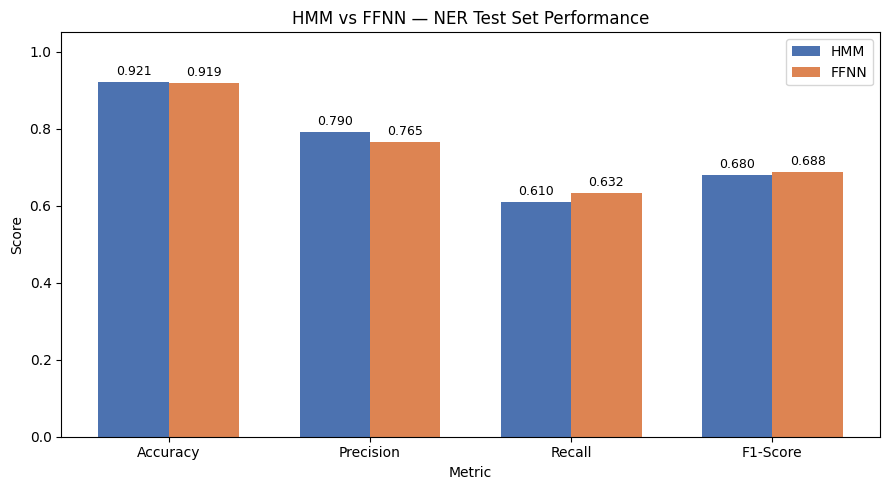

In [6]:
import pandas as pd
import matplotlib.pyplot as plt

#  HMM -> weighted avg on entity tags only (excluding 'O')
#  FFNN -> macro avg across all 9 tags
hmm_results = {
    "Accuracy" : 0.9211,  
    "Precision": 0.79,   
    "Recall"   : 0.61,  
    "F1-Score" : 0.68,   
}

ffnn_results = {
    "Accuracy" : 0.9191,
    "Precision": 0.7646,
    "Recall"   : 0.6316,
    "F1-Score" : 0.6880,
}

comparison = pd.DataFrame({
    "Metric" : list(hmm_results.keys()),
    "HMM"    : list(hmm_results.values()),
    "FFNN"   : list(ffnn_results.values()),
})
comparison["Winner"] = comparison.apply(
    lambda row: "FFNN" if row["FFNN"] > row["HMM"] else "HMM", axis=1
)
print("=== Model Comparison: HMM vs Feed-Forward Neural Network ===")
print(comparison.to_string(index=False))

metrics = list(hmm_results.keys())
x = range(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))
bars1 = ax.bar([i - width/2 for i in x], hmm_results.values(),  width, label="HMM",  color="#4C72B0")
bars2 = ax.bar([i + width/2 for i in x], ffnn_results.values(), width, label="FFNN", color="#DD8452")

ax.set_xlabel("Metric")
ax.set_ylabel("Score")
ax.set_title("HMM vs FFNN — NER Test Set Performance")
ax.set_xticks(list(x))
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1.05)
ax.legend()
ax.bar_label(bars1, fmt="%.3f", padding=3, fontsize=9)
ax.bar_label(bars2, fmt="%.3f", padding=3, fontsize=9)
plt.tight_layout()
plt.show()